In [3]:
#Set up Pyspark

In [11]:
import matplotlib.pyplot as plt
import seaborn as sns 
from pyspark.sql import SparkSession
from pyspark.sql.functions import col

spark = SparkSession.builder\
    .appName("EDA")\
    .getOrCreate()


## Load data

In [31]:
#Load data

### Clickstream feature

In [9]:
clickstream = spark.read.csv("data/feature_clickstream.csv", header = True, inferSchema = True)
clickstream.printSchema()

root
 |-- fe_1: integer (nullable = true)
 |-- fe_2: integer (nullable = true)
 |-- fe_3: integer (nullable = true)
 |-- fe_4: integer (nullable = true)
 |-- fe_5: integer (nullable = true)
 |-- fe_6: integer (nullable = true)
 |-- fe_7: integer (nullable = true)
 |-- fe_8: integer (nullable = true)
 |-- fe_9: integer (nullable = true)
 |-- fe_10: integer (nullable = true)
 |-- fe_11: integer (nullable = true)
 |-- fe_12: integer (nullable = true)
 |-- fe_13: integer (nullable = true)
 |-- fe_14: integer (nullable = true)
 |-- fe_15: integer (nullable = true)
 |-- fe_16: integer (nullable = true)
 |-- fe_17: integer (nullable = true)
 |-- fe_18: integer (nullable = true)
 |-- fe_19: integer (nullable = true)
 |-- fe_20: integer (nullable = true)
 |-- Customer_ID: string (nullable = true)
 |-- snapshot_date: date (nullable = true)



In [10]:
clickstream.show(5)

+----+----+----+----+----+----+----+----+----+-----+-----+-----+-----+-----+-----+-----+-----+-----+-----+-----+-----------+-------------+
|fe_1|fe_2|fe_3|fe_4|fe_5|fe_6|fe_7|fe_8|fe_9|fe_10|fe_11|fe_12|fe_13|fe_14|fe_15|fe_16|fe_17|fe_18|fe_19|fe_20|Customer_ID|snapshot_date|
+----+----+----+----+----+----+----+----+----+-----+-----+-----+-----+-----+-----+-----+-----+-----+-----+-----+-----------+-------------+
|  63| 118|  80| 121|  55| 193| 111| 112|-101|   83|  164|  105|  -16|  -81| -126|  114|   35|   85|  -73|   76| CUS_0x1037|   2023-01-01|
|-108| 182| 123|   4| -56|  27|  25|  -6| 284|  222|  203|  190|  -14|  -96|  200|   35|  130|   94|  111|   75| CUS_0x1069|   2023-01-01|
| -13|   8|  87| 166| 214| -98| 215| 152| 129|  139|   14|  203|   26|   86|  171|  125| -130|  354|   17|  302| CUS_0x114a|   2023-01-01|
| -85|  45| 200|  89| 128|  54|  76|  51|  61|  139|    6|  197|  172|   96|  174|  163|   37|  207|  180|  118| CUS_0x1184|   2023-01-01|
|  55| 120| 226| -86| 253| 

In [11]:
clickstream.describe().show()

+-------+------------------+------------------+------------------+------------------+------------------+------------------+------------------+------------------+------------------+------------------+------------------+------------------+------------------+------------------+------------------+------------------+------------------+------------------+------------------+------------------+-----------+
|summary|              fe_1|              fe_2|              fe_3|              fe_4|              fe_5|              fe_6|              fe_7|              fe_8|              fe_9|             fe_10|             fe_11|             fe_12|             fe_13|             fe_14|             fe_15|             fe_16|             fe_17|             fe_18|             fe_19|             fe_20|Customer_ID|
+-------+------------------+------------------+------------------+------------------+------------------+------------------+------------------+------------------+------------------+----------------

In [34]:
df_clickstream = spark.read.parquet("datamart/silver/clickstream_clean")
df_clickstream.printSchema()
df_clickstream.show(5)

df_clickstream.toPandas().to_csv("preview_silver_clickstream.csv", index=False)


root
 |-- fe_1: integer (nullable = true)
 |-- fe_2: integer (nullable = true)
 |-- fe_3: integer (nullable = true)
 |-- fe_4: integer (nullable = true)
 |-- fe_5: integer (nullable = true)
 |-- fe_6: integer (nullable = true)
 |-- fe_7: integer (nullable = true)
 |-- fe_8: integer (nullable = true)
 |-- fe_9: integer (nullable = true)
 |-- fe_10: integer (nullable = true)
 |-- fe_11: integer (nullable = true)
 |-- fe_12: integer (nullable = true)
 |-- fe_13: integer (nullable = true)
 |-- fe_14: integer (nullable = true)
 |-- fe_15: integer (nullable = true)
 |-- fe_16: integer (nullable = true)
 |-- fe_17: integer (nullable = true)
 |-- fe_18: integer (nullable = true)
 |-- fe_19: integer (nullable = true)
 |-- fe_20: integer (nullable = true)
 |-- Customer_ID: string (nullable = true)
 |-- snapshot_date: date (nullable = true)

+----+----+----+----+----+----+----+----+----+-----+-----+-----+-----+-----+-----+-----+-----+-----+-----+-----+-----------+-------------+
|fe_1|fe_2|fe_3|fe

### Attributes feature

In [13]:
attributes = spark.read.csv("data/features_attributes.csv", header = True, inferSchema=True)
attributes.printSchema()
attributes.show(5)

root
 |-- Customer_ID: string (nullable = true)
 |-- Name: string (nullable = true)
 |-- Age: string (nullable = true)
 |-- SSN: string (nullable = true)
 |-- Occupation: string (nullable = true)
 |-- snapshot_date: date (nullable = true)

+-----------+--------------+---+-----------+-------------+-------------+
|Customer_ID|          Name|Age|        SSN|   Occupation|snapshot_date|
+-----------+--------------+---+-----------+-------------+-------------+
| CUS_0x1000|Alistair Barrf| 18|913-74-1218|       Lawyer|   2023-05-01|
| CUS_0x1009|        Arunah| 26|063-67-6938|     Mechanic|   2025-01-01|
| CUS_0x100b|      Shirboni| 19|  #F%$D@*&8|Media_Manager|   2024-03-01|
| CUS_0x1011|     Schneyerh| 44|793-05-8223|       Doctor|   2023-11-01|
| CUS_0x1013|      Cameront| 44|930-49-9615|     Mechanic|   2023-12-01|
+-----------+--------------+---+-----------+-------------+-------------+
only showing top 5 rows



In [33]:
from pyspark.sql import SparkSession
from pyspark.sql.functions import col, count, when

spark = SparkSession.builder.getOrCreate()

# Load cleaned attributes data
df_attributes = spark.read.parquet("datamart/silver/attributes_clean")

# Check schema
df_attributes.printSchema()

# Show sample rows
df_attributes.show(5, truncate=False)

# Count nulls per column
df_attributes.select([count(when(col(c).isNull(), c)).alias(c) for c in df_attributes.columns]).show()

# Check unique values in Occupation
df_attributes.groupBy("Occupation").count().orderBy("count", ascending=False).show(30, truncate=False)

# Check invalid SSN (should be empty if cleaned properly)
df_attributes.filter(~col("SSN").rlike("^\\d{3}-\\d{2}-\\d{4}$")).select("SSN").distinct().show(30, truncate=False)

# Export preview CSV if needed
df_attributes.limit(1000).toPandas().to_csv("preview_silver_attributes.csv", index=False)


root
 |-- Customer_ID: string (nullable = true)
 |-- Name: string (nullable = true)
 |-- Age: integer (nullable = true)
 |-- SSN: string (nullable = true)
 |-- Occupation: string (nullable = true)
 |-- snapshot_date: date (nullable = true)

+-----------+--------------+---+-----------+-------------+-------------+
|Customer_ID|Name          |Age|SSN        |Occupation   |snapshot_date|
+-----------+--------------+---+-----------+-------------+-------------+
|CUS_0x1000 |Alistair Barrf|18 |913-74-1218|Lawyer       |2023-05-01   |
|CUS_0x1009 |Arunah        |26 |063-67-6938|Mechanic     |2025-01-01   |
|CUS_0x100b |Shirboni      |19 |NULL       |Media_Manager|2024-03-01   |
|CUS_0x1011 |Schneyerh     |44 |793-05-8223|Doctor       |2023-11-01   |
|CUS_0x1013 |Cameront      |44 |930-49-9615|Mechanic     |2023-12-01   |
+-----------+--------------+---+-----------+-------------+-------------+
only showing top 5 rows

+-----------+----+---+---+----------+-------------+
|Customer_ID|Name|Age|SSN

### Financials feature 

financials = spark.read.csv("data/features_financials.csv", header = True, inferSchema = True)
financials.printSchema()
financials.show(5)

Plotting Annual income

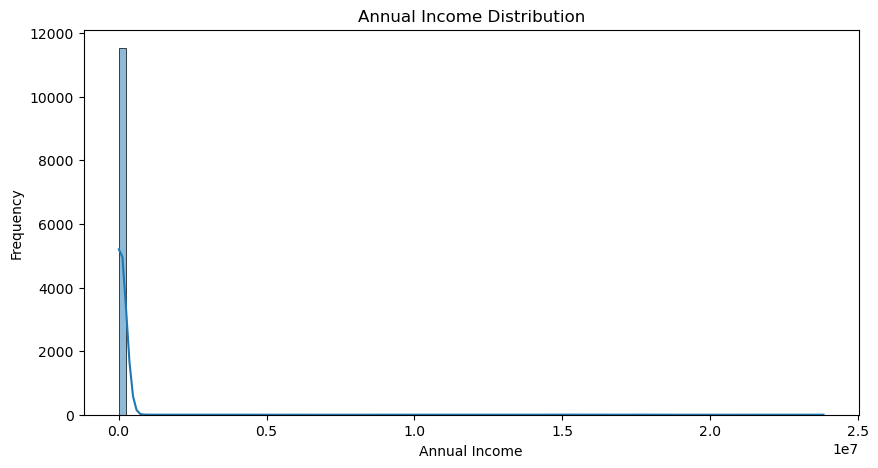

In [13]:
financials = financials.replace(["_", "NA"], None) 
financials_cast = financials.withColumn("Annual_Income", col("Annual_Income").cast("double"))

pdf = financials_cast.select("Annual_Income").dropna().toPandas()
# Plot
plt.figure(figsize=(10,5))
sns.histplot(pdf["Annual_Income"], bins=100, kde=True)
plt.title("Annual Income Distribution")
plt.xlabel("Annual Income")
plt.ylabel("Frequency")
plt.show()

Annual income seems to be right-skewed, with many small income and some few extremely large income. 

In [15]:
pdf["Annual_Income"].sort_values(ascending=False).head(20)


4791     23834698.0
4112     22409880.0
2066     22225113.0
3875     22136920.0
7056     21964843.0
7714     21762134.0
2595     21752116.0
7739     21001046.0
8526     20501034.0
4122     20441835.0
10008    20368494.0
11422    19768015.0
207      19473209.0
11498    19134169.0
9832     18884777.0
671      18320277.0
9476     17938268.0
6878     17872695.0
4784     17741279.0
356      17706148.0
Name: Annual_Income, dtype: float64

In [16]:
q99 = pdf["Annual_Income"].quantile(0.99)
trimmed = pdf[pdf["Annual_Income"] < q99]
trimmed["Annual_Income"].median()


36886.274999999994

In [18]:
from pyspark.sql.functions import col, count, when

total = financials.count()
missing = financials.filter(col("Annual_Income").isNull()).count()
pct_missing = (missing / total) * 100
print(f"Missing % = {pct_missing:.2f}%")


Missing % = 0.00%


Checking valid payment behaviours

In [20]:
financials.select("Payment_Behaviour").distinct().orderBy("Payment_Behaviour").show(truncate=False)


+--------------------------------+
|Payment_Behaviour               |
+--------------------------------+
|!@9#%8                          |
|High_spent_Large_value_payments |
|High_spent_Medium_value_payments|
|High_spent_Small_value_payments |
|Low_spent_Large_value_payments  |
|Low_spent_Medium_value_payments |
|Low_spent_Small_value_payments  |
+--------------------------------+



In [21]:
financials.select("Credit_History_Age").distinct().orderBy("Payment_Behaviour").show(truncate=False)


+----------------------+
|Credit_History_Age    |
+----------------------+
|17 Years and 8 Months |
|32 Years and 8 Months |
|17 Years and 9 Months |
|12 Years and 8 Months |
|2 Years and 10 Months |
|16 Years and 0 Months |
|2 Years and 3 Months  |
|25 Years and 4 Months |
|27 Years and 11 Months|
|1 Years and 2 Months  |
|27 Years and 6 Months |
|16 Years and 3 Months |
|28 Years and 1 Months |
|21 Years and 8 Months |
|3 Years and 5 Months  |
|23 Years and 1 Months |
|30 Years and 0 Months |
|24 Years and 5 Months |
|30 Years and 10 Months|
|17 Years and 7 Months |
+----------------------+
only showing top 20 rows



In [22]:
financials.select("Type_of_Loan").distinct().orderBy("Payment_Behaviour").show(truncate=False)


+---------------------------------------------------------------------------------------------------------------------------------------+
|Type_of_Loan                                                                                                                           |
+---------------------------------------------------------------------------------------------------------------------------------------+
|Auto Loan, Debt Consolidation Loan, Not Specified, Credit-Builder Loan, Personal Loan, Home Equity Loan, Payday Loan, and Not Specified|
|Auto Loan, Not Specified, Personal Loan, Personal Loan, and Auto Loan                                                                  |
|Auto Loan, Debt Consolidation Loan, Student Loan, Personal Loan, Home Equity Loan, and Student Loan                                    |
|Auto Loan, Debt Consolidation Loan, Mortgage Loan, and Not Specified                                                                   |
|Auto Loan, Debt Consolidation Loa

##### Test financials_clean

In [24]:
df = spark.read.parquet("datamart/silver/financials_clean")
df.printSchema()

root
 |-- Customer_ID: string (nullable = true)
 |-- Annual_Income: double (nullable = true)
 |-- Monthly_Inhand_Salary: double (nullable = true)
 |-- Num_Bank_Accounts: integer (nullable = true)
 |-- Num_Credit_Card: integer (nullable = true)
 |-- Interest_Rate: integer (nullable = true)
 |-- Num_of_Loan: integer (nullable = true)
 |-- Type_of_Loan: string (nullable = true)
 |-- Delay_from_due_date: integer (nullable = true)
 |-- Num_of_Delayed_Payment: integer (nullable = true)
 |-- Changed_Credit_Limit: double (nullable = true)
 |-- Num_Credit_Inquiries: integer (nullable = true)
 |-- Credit_Mix: string (nullable = true)
 |-- Outstanding_Debt: double (nullable = true)
 |-- Credit_Utilization_Ratio: double (nullable = true)
 |-- Credit_History_Age: string (nullable = true)
 |-- Payment_of_Min_Amount: string (nullable = true)
 |-- Total_EMI_per_month: double (nullable = true)
 |-- Amount_invested_monthly: double (nullable = true)
 |-- Payment_Behaviour: string (nullable = true)
 |-- M

In [27]:
df.select("Payment_Behaviour").distinct().orderBy("Payment_Behaviour").show(1000, truncate=False)


+--------------------------------+
|Payment_Behaviour               |
+--------------------------------+
|NULL                            |
|High_spent_Large_value_payments |
|High_spent_Medium_value_payments|
|High_spent_Small_value_payments |
|Low_spent_Large_value_payments  |
|Low_spent_Medium_value_payments |
|Low_spent_Small_value_payments  |
+--------------------------------+



In [28]:
df.select("Num_of_Loan").distinct().orderBy("Payment_Behaviour").show(1000, truncate=False)


+-----------+
|Num_of_Loan|
+-----------+
|4          |
|6          |
|7          |
|18         |
|65         |
|1085       |
|1159       |
|1412       |
|237        |
|455        |
|614        |
|795        |
|945        |
|999        |
|1053       |
|1480       |
|1          |
|2          |
|3          |
|5          |
|365        |
|387        |
|404        |
|1127       |
|1384       |
|1393       |
|83         |
|119        |
|192        |
|251        |
|781        |
|860        |
|1070       |
|1137       |
|1257       |
|8          |
|55         |
|58         |
|146        |
|227        |
|438        |
|699        |
|917        |
|1478       |
|1495       |
|27         |
|33         |
|103        |
|497        |
|520        |
|653        |
|1091       |
|0          |
|9          |
|31         |
|87         |
|100        |
|172        |
|186        |
|285        |
|332        |
|420        |
|439        |
|463        |
|777        |
|785        |
|799        |
|966        |
|1014 

In [29]:
df.select("Num_of_Loan").distinct().orderBy("Payment_Behaviour").show(1000, truncate=False)


+-----------+
|Num_of_Loan|
+-----------+
|4          |
|6          |
|7          |
|18         |
|65         |
|1085       |
|1159       |
|1412       |
|237        |
|455        |
|614        |
|795        |
|945        |
|999        |
|1053       |
|1480       |
|1          |
|2          |
|3          |
|5          |
|365        |
|387        |
|404        |
|1127       |
|1384       |
|1393       |
|83         |
|119        |
|192        |
|251        |
|781        |
|860        |
|1070       |
|1137       |
|1257       |
|8          |
|55         |
|58         |
|146        |
|227        |
|438        |
|699        |
|917        |
|1478       |
|1495       |
|27         |
|33         |
|103        |
|497        |
|520        |
|653        |
|1091       |
|0          |
|9          |
|31         |
|87         |
|100        |
|172        |
|186        |
|285        |
|332        |
|420        |
|439        |
|463        |
|777        |
|785        |
|799        |
|966        |
|1014 

In [26]:
from pyspark.sql.functions import col, isnan, count

df.select([count(when(col(c).isNull(), c)).alias(c) for c in df.columns]).show()


+-----------+-------------+---------------------+-----------------+---------------+-------------+-----------+------------+-------------------+----------------------+--------------------+--------------------+----------+----------------+------------------------+------------------+---------------------+-------------------+-----------------------+-----------------+---------------+-------------+----------------+
|Customer_ID|Annual_Income|Monthly_Inhand_Salary|Num_Bank_Accounts|Num_Credit_Card|Interest_Rate|Num_of_Loan|Type_of_Loan|Delay_from_due_date|Num_of_Delayed_Payment|Changed_Credit_Limit|Num_Credit_Inquiries|Credit_Mix|Outstanding_Debt|Credit_Utilization_Ratio|Credit_History_Age|Payment_of_Min_Amount|Total_EMI_per_month|Amount_invested_monthly|Payment_Behaviour|Monthly_Balance|snapshot_date|Loan_Types_Array|
+-----------+-------------+---------------------+-----------------+---------------+-------------+-----------+------------+-------------------+----------------------+-------------

In [30]:
df.toPandas().to_csv("preview_silver_financials.csv", index=False)


### Loan 

In [15]:
loans = spark.read.csv("data/lms_loan_daily.csv", header=True, inferSchema=True)
loans.printSchema()
loans.show(5)


root
 |-- loan_id: string (nullable = true)
 |-- Customer_ID: string (nullable = true)
 |-- loan_start_date: date (nullable = true)
 |-- tenure: integer (nullable = true)
 |-- installment_num: integer (nullable = true)
 |-- loan_amt: integer (nullable = true)
 |-- due_amt: double (nullable = true)
 |-- paid_amt: double (nullable = true)
 |-- overdue_amt: double (nullable = true)
 |-- balance: double (nullable = true)
 |-- snapshot_date: date (nullable = true)

+--------------------+-----------+---------------+------+---------------+--------+-------+--------+-----------+-------+-------------+
|             loan_id|Customer_ID|loan_start_date|tenure|installment_num|loan_amt|due_amt|paid_amt|overdue_amt|balance|snapshot_date|
+--------------------+-----------+---------------+------+---------------+--------+-------+--------+-----------+-------+-------------+
|CUS_0x1000_2023_0...| CUS_0x1000|     2023-05-01|    10|              0|   10000|    0.0|     0.0|        0.0|10000.0|   2023-05-01|

In [35]:
df_loans = spark.read.parquet("datamart/silver/loans_clean")
df_loans.select("Customer_ID", "loan_id", "dpd", "mob", "installments_missed").show(5)
df_loans.toPandas().to_csv("loans_clean_sample.csv", index=False)


+-----------+--------------------+---+---+-------------------+
|Customer_ID|             loan_id|dpd|mob|installments_missed|
+-----------+--------------------+---+---+-------------------+
| CUS_0x5012|CUS_0x5012_2023_1...|184| 10|                  6|
| CUS_0x501c|CUS_0x501c_2024_0...| 92|  6|                  3|
| CUS_0x501d|CUS_0x501d_2024_0...|  0|  7|                  0|
| CUS_0x5035|CUS_0x5035_2023_1...|  0|  9|                  0|
| CUS_0x5044|CUS_0x5044_2024_0...|  0|  8|                  0|
+-----------+--------------------+---+---+-------------------+
only showing top 5 rows

